# Phase5: Factor Combination

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
from typing import Dict, Callable
from sklearn.linear_model import Ridge, Lasso, ElasticNet, HuberRegressor, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb
from catboost import CatBoostRegressor
import optuna

/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_5142/4108135008.py:29: RuntimeWarning: Failed to read close_df.parquet as parquet (Repetition level histogram size mismatch). Falling back to close_df.pkl.
  warnings.warn(
/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_5142/4108135008.py:29: RuntimeWarning: Failed to read returns_df.parquet as parquet (Repetition level histogram size mismatch). Falling back to returns_df.pkl.
  warnings.warn(
/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_5142/4108135008.py:29: RuntimeWarning: Failed to read open_df.parquet as parquet (Repetition level histogram size mismatch). Falling back to open_df.pkl.
  warnings.warn(
/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_5142/4108135008.py:29: RuntimeWarning: Failed to read high_df.parquet as parquet (Repetition level histogram size mismatch). Falling back to high_df.pkl.
  warnings.warn(
/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_5142/41081350

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_5142/3468435781.py:28: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = close.pct_change()
/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_5142/2569342948.py:18: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fwd = prices.pct_change(p).shift(-p)
/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_5142/2569342948.py:18: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change

===== Performance Summary =====
Periods             : 2253
Total Return        :   78.14%
CAGR                :    6.67%
Ann. Volatility     :   20.20%
Sharpe Ratio        :     0.33
Max Drawdown        :  -42.52%
Calmar Ratio        :     0.16
Hit Rate (p>0)      :   53.40%


/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_5142/3272765553.py:13: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret = close.pct_change()          # daily returns


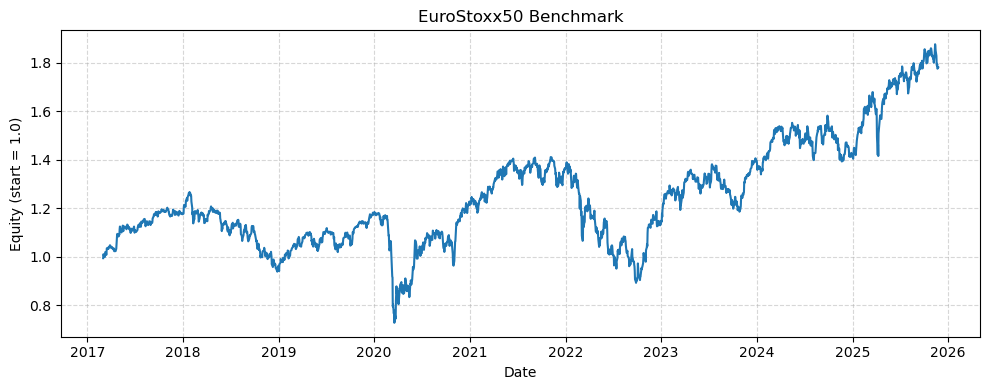

Requested 22 alphas.
Collected  22 DataFrames.
Common tickers across prices + all alphas: 50


,alpha,start_date_nonnull,end_date,avg_names_per_day,median_names_per_day,overall_coverage_frac
0,alpha11,2014-12-30,2025-12-31,48.423855,49.0,1.000000
1,alpha7,2014-12-30,2025-12-31,48.423855,49.0,1.000000
2,alpha19,2015-01-02,2025-12-31,48.416755,49.0,0.999853
3,alpha9,2015-06-08,2025-12-31,46.660987,49.0,0.963595
4,alpha12,2014-12-30,2025-12-31,46.384807,47.0,0.957892
5,alpha_nltsmom,2015-12-28,2025-12-31,43.950302,48.0,0.907617
6,alpha10,2015-03-30,2025-12-31,39.325169,49.0,0.812103
7,alpha5,2016-12-15,2025-12-31,39.020234,49.0,0.805806
8,alpha17,2016-05-09,2025-12-31,32.352858,42.0,0.668118
9,alpha6,2017-03-27,2025-12-31,31.164004,43.0,0.643567


Built cleaned alpha versions:
 - alpha_aligned: raw aligned
 - alpha_clip_z: winsorized + cross-sectional z-score
 - alpha_rank: cross-sectional ranks in [-0.5, 0.5]
Core set (high coverage): ['alpha11', 'alpha7', 'alpha19', 'alpha9', 'alpha12', 'alpha_nltsmom', 'alpha10', 'alpha5']
Broad pool (looser thresholds): ['alpha11', 'alpha7', 'alpha19', 'alpha9', 'alpha12', 'alpha_nltsmom', 'alpha10', 'alpha5', 'alpha17', 'alpha6', 'alpha2', 'alpha13', 'alpha1', 'alpha4', 'alpha3', 'alpha16']
Common-sample days: 1272 out of 2817
Common-sample start: 2019-12-19 00:00:00
Common-sample end: 2025-12-23 00:00:00
Latest start (broad pool): 2017-04-28 00:00:00
Latest start (core set): 2016-12-15 00:00:00
X_rank shape: (1272, 800)   (#dates x (#alphas * #tickers))
X_z    shape: (1272, 800)
R_fwd  shape: (1272, 50)
K_MIN_FACTORS = 11
Avg names/day in sample: 48.106918238993714
Median names/day in sample: 48.0


/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_5142/2445840667.py:16: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  R_fwd = px_close.pct_change(H).shift(-H)
/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_5142/2445840667.py:55: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  avail_counts = avail.groupby(level="ticker", axis=1).sum()  # sum over alpha columns per ticker


Date
2020-03-12    42
2020-11-30    43
2022-08-15    43
2024-08-15    44
2025-08-15    44
2020-05-04    44
2020-11-26    44
2020-08-27    44
2020-11-23    44
2023-08-15    44
Name: names_in_sample_bottom10, dtype: int64

...

,alpha7,alpha9,alpha12,alpha_nltsmom,alpha5,alpha17,alpha2,alpha13,alpha1,alpha4,alpha3,alpha6,alpha11
alpha7,1.000000,0.064054,0.020134,0.128002,-0.061713,0.030187,0.012742,0.135783,0.069940,0.084610,0.049608,0.010322,0.185244
alpha9,0.064054,1.000000,0.021188,0.137491,0.003992,0.049989,0.005212,0.165599,0.035188,-0.008760,-0.014647,0.038148,0.062365
alpha12,0.020134,0.021188,1.000000,0.037304,-0.010941,0.018084,-0.000021,0.209970,-0.020372,0.014214,-0.006106,0.011518,0.025838
alpha_nltsmom,0.128002,0.137491,0.037304,1.000000,-0.041271,0.120278,0.014079,0.413533,0.072461,0.080380,-0.036394,0.005007,0.232131
alpha5,-0.061713,0.003992,-0.010941,-0.041271,1.000000,-0.047194,-0.049608,-0.000762,0.002373,-0.089462,-0.110590,-0.224769,-0.059634
alpha17,0.030187,0.049989,0.018084,0.120278,-0.047194,1.000000,0.037861,0.059610,0.022809,0.038147,-0.054993,0.010264,0.015183
alpha2,0.012742,0.005212,-0.000021,0.014079,-0.049608,0.037861,1.000000,-0.003051,-0.016780,0.021329,0.070881,-0.066503,0.004022
alpha13,0.135783,0.165599,0.209970,0.413533,-0.000762,0.059610,-0.003051,1.000000,0.120589,0.086738,0.033489,-0.004674,0.344023
alpha1,0.069940,0.035188,-0.020372,0.072461,0.002373,0.022809,-0.016780,0.120589,1.000000,0.433238,0.174759,0.027251,0.097029
alpha4,0.084610,-0.008760,0.014214,0.080380,-0.089462,0.038147,0.021329,0.086738,0.433238,1.000000,0.179539,0.058389,0.145994


,alpha7,alpha9,alpha12,alpha_nltsmom,alpha5,alpha17,alpha2,alpha13,alpha1,alpha4,alpha3,alpha6,alpha11
alpha7,1272,1272,1272,1272,1272,1272,1272,1272,1272,1272,1272,1233,947
alpha9,1272,1272,1272,1272,1272,1272,1272,1272,1272,1272,1272,1233,947
alpha12,1272,1272,1272,1272,1272,1266,1266,1263,1266,1266,1266,1229,938
alpha_nltsmom,1272,1272,1272,1272,1272,1272,1272,1272,1272,1272,1272,1233,947
alpha5,1272,1272,1272,1272,1272,1272,1272,1272,1272,1272,1272,1233,947
alpha17,1272,1272,1266,1272,1272,1272,1269,1272,1272,1272,1272,1233,947
alpha2,1272,1272,1266,1272,1272,1269,1272,1269,1271,1272,1271,1228,947
alpha13,1272,1272,1263,1272,1272,1272,1269,1272,1272,1272,1272,1233,947
alpha1,1272,1272,1266,1272,1272,1272,1271,1272,1272,1272,1272,1233,947
alpha4,1272,1272,1266,1272,1272,1272,1272,1272,1272,1272,1272,1233,947


,min_pairwise_days,median_pairwise_days
alpha6,911,1233.0
alpha11,911,947.0
alpha12,938,1266.0
alpha7,947,1272.0
alpha9,947,1272.0
alpha_nltsmom,947,1272.0
alpha5,947,1272.0
alpha17,947,1272.0
alpha2,947,1271.0
alpha13,947,1272.0


,alpha_i,alpha_j,mean_spearman,N_days
0,alpha1,alpha4,0.433238,1272
1,alpha_nltsmom,alpha13,0.413533,1272
2,alpha13,alpha11,0.344023,947


#factors used: 13
min eig: 0.494342  max eig: 2.02406
condition number: 4.09
effective rank: 12.13


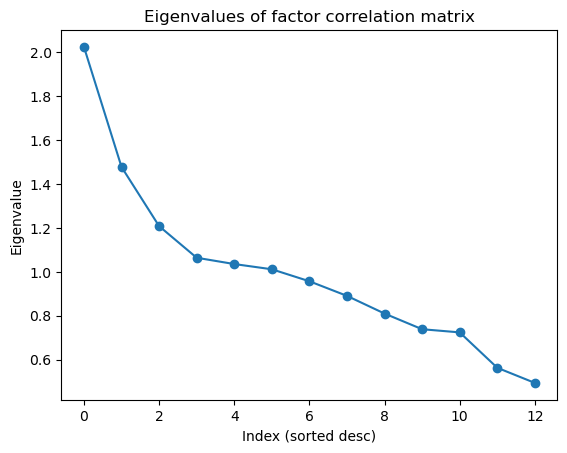

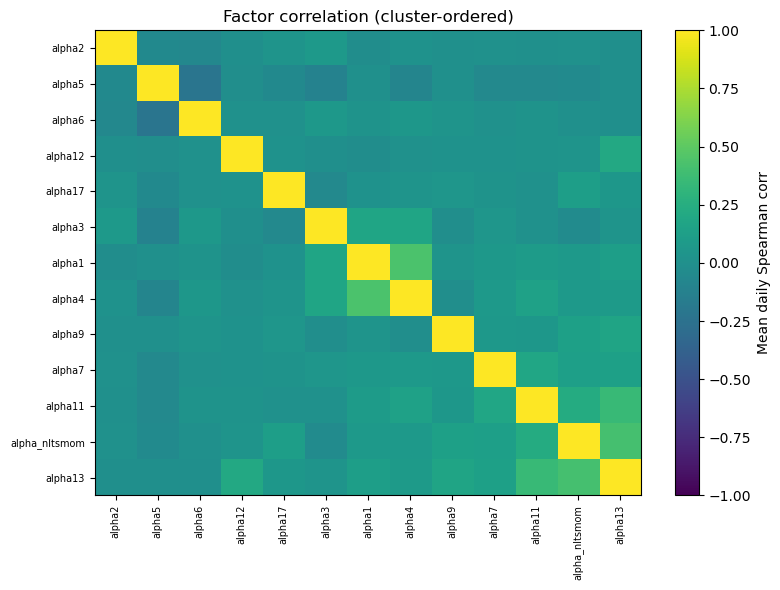

Factor returns panel B shape: (1272, 13)


,nobs,r2,intercept
count,1272.000000,1272.000000,1272.000000
mean,48.106918,0.355059,0.000651
std,1.166494,0.118290,0.012869
min,42.000000,0.062300,-0.129809
25%,48.000000,0.269954,-0.004443
50%,48.000000,0.346156,0.000854
75%,49.000000,0.429171,0.006637
max,49.000000,0.781796,0.100621


,alpha7,alpha9,alpha12,alpha_nltsmom,alpha5,alpha17,alpha2,alpha13,alpha1,alpha4,alpha3,alpha6,alpha11
alpha7,1.000000,0.015932,-0.089106,-0.097126,-0.024525,-0.032962,0.113364,-0.033401,-0.008475,-0.104537,0.151657,0.048276,-0.128994
alpha9,0.015932,1.000000,-0.075351,-0.212237,0.000464,-0.017468,0.084782,-0.023743,-0.036418,0.050714,0.109404,-0.059632,0.066843
alpha12,-0.089106,-0.075351,1.000000,0.070074,-0.034044,-0.000800,0.012868,-0.106763,0.056290,0.025305,-0.064144,-0.005582,-0.015063
alpha_nltsmom,-0.097126,-0.212237,0.070074,1.000000,0.025528,-0.035436,0.014889,-0.350540,0.019754,-0.023790,-0.119735,0.004218,-0.111209
alpha5,-0.024525,0.000464,-0.034044,0.025528,1.000000,0.091228,-0.013902,-0.001105,-0.109187,0.178709,0.065726,0.147169,0.016540
alpha17,-0.032962,-0.017468,-0.000800,-0.035436,0.091228,1.000000,-0.111046,-0.049571,0.048446,0.028544,0.022117,0.045058,0.006794
alpha2,0.113364,0.084782,0.012868,0.014889,-0.013902,-0.111046,1.000000,0.081662,0.041883,-0.096836,-0.017259,-0.056269,-0.027734
alpha13,-0.033401,-0.023743,-0.106763,-0.350540,-0.001105,-0.049571,0.081662,1.000000,-0.009595,-0.011189,-0.010068,-0.017992,-0.120893
alpha1,-0.008475,-0.036418,0.056290,0.019754,-0.109187,0.048446,0.041883,-0.009595,1.000000,-0.437202,0.008220,-0.060591,-0.021988
alpha4,-0.104537,0.050714,0.025305,-0.023790,0.178709,0.028544,-0.096836,-0.011189,-0.437202,1.000000,-0.235600,0.007485,-0.000584


,mean_beta,std_beta,tstat_iid
alpha1,0.000227,0.003265,2.478811
alpha13,0.000216,0.004109,1.873592
alpha17,0.000074,0.002473,1.064780
alpha3,0.000087,0.003115,0.999195
alpha5,0.000079,0.002885,0.981518
alpha2,0.000061,0.002798,0.782293
alpha_nltsmom,0.000086,0.004999,0.613589
alpha12,0.000043,0.003516,0.432442
alpha4,0.000003,0.003625,0.034025
alpha9,-0.000023,0.002962,-0.280108


NW t-stats:


alpha1           2.610016
alpha13          1.958875
alpha17          1.172809
alpha3           0.980502
alpha5           0.966095
alpha2           0.737487
alpha_nltsmom    0.636269
alpha12          0.399894
alpha4           0.035647
alpha9          -0.255834
alpha6          -0.610303
alpha11         -1.075797
alpha7          -1.107261
dtype: float64

Weights panel shape: (1212, 13)
Combined score panel S shape: (1212, 49)
IC mean: 0.003532046884753667 IC std: 0.18748414947628578 ICIR: 0.018839175976315927


count    1212.000000
mean        0.003532
std         0.187484
min        -0.541166
25%        -0.128911
50%         0.007449
75%         0.125717
max         0.628061
dtype: float64

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/opt/anaconda3/lib/python3.12/

,alpha,ic_mean,ic_std,icir,hit_rate,n_days
0,alpha1,0.011061,0.167056,0.066210,0.522013,1272
1,alpha2,0.010569,0.167560,0.063078,0.514937,1272
2,alpha9,0.011359,0.183689,0.061838,0.538522,1272
3,alpha12,0.013165,0.215778,0.061012,0.533071,1270
4,alpha5,0.009819,0.177967,0.055175,0.514937,1272
5,alpha13,0.008245,0.220236,0.037438,0.509434,1272
6,alpha17,0.004763,0.151401,0.031456,0.511792,1272
7,alpha3,0.005072,0.184032,0.027561,0.518082,1272
8,alpha4,-0.002898,0.182349,-0.015892,0.494497,1272
9,alpha6,-0.004241,0.149433,-0.028380,0.471698,1233


In [4]:
%run "./Collinearity Analysis.ipynb"

## 5.1 Evaluation Utilities

In [5]:
def daily_spearman_ic(pred: pd.Series, y: pd.Series, min_names=30) -> pd.Series:
    """
    pred, y: indexed by (date,ticker)
    Returns daily IC series indexed by date
    """
    df = pd.DataFrame({"pred": pred, "y": y}).dropna()
    out = {}
    for d, g in df.groupby(level="date"):
        if len(g) >= min_names:
            out[d] = g["pred"].corr(g["y"], method="spearman")
    return pd.Series(out).sort_index()

def daily_ls_spread(pred: pd.Series, y: pd.Series, q=0.2, min_names=30) -> pd.Series:
    """
    Simple top-bottom quantile spread in returns using predictions for ranking.
    """
    df = pd.DataFrame({"pred": pred, "y": y}).dropna()
    out = {}
    for d, g in df.groupby(level="date"):
        if len(g) < min_names:
            continue
        g = g.sort_values("pred")
        n = len(g)
        k = int(np.floor(q * n))
        if k < 1:
            continue
        bot = g.iloc[:k]["y"].mean()
        top = g.iloc[-k:]["y"].mean()
        out[d] = float(top - bot)
    return pd.Series(out).sort_index()

def summarize_series(s: pd.Series, name="metric") -> pd.Series:
    mu = float(s.mean())
    sd = float(s.std(ddof=1))
    return pd.Series({
        f"{name}_mean": mu,
        f"{name}_std": sd,
        f"{name}_ir": (mu / sd) if sd > 0 else np.nan,
        f"{name}_n": int(s.notna().sum()),
    })

## 5.2 ICIR Weighted

## Benchmark: Equal Weight

In [6]:
def score_from_weights(X_row: pd.Series, w: pd.Series) -> pd.Series:
    """Compute score per ticker from one day's (alpha,ticker) exposures and alpha weights."""
    Xmat = X_row.unstack("alpha").reindex(columns=w.index)
    Xmat = Xmat.fillna(0.0)
    s = Xmat.values @ w.values
    return pd.Series(s, index=Xmat.index)

# Equal-weight across factors (rank exposures)
w_eq = pd.Series(1.0, index=ALPHAS2)
w_eq = w_eq / w_eq.abs().sum()

scores = []
for t in dates:
    xrow = X_rank.loc[t]
    s = score_from_weights(xrow, w_eq)
    m = sample_mask.loc[t] & R_fwd_s.loc[t].notna()
    scores.append(s.where(m).rename(t))

S_eq = pd.DataFrame(scores).sort_index()

ic_eq = daily_ic_from_panels(S_eq, R_fwd_s, sample_mask, method="spearman", min_names=MIN_NAMES)
print("Equal-weight combo IC mean/std/ICIR:",
      float(ic_eq.mean()),
      float(ic_eq.std(ddof=1)),
      float(ic_eq.mean()/ic_eq.std(ddof=1)) if ic_eq.std(ddof=1)>0 else np.nan)
display(ic_eq.describe())

Equal-weight combo IC mean/std/ICIR: 0.011299834057390481 0.19504966480735833 0.05793311190024762


count    1272.000000
mean        0.011300
std         0.195050
min        -0.635816
25%        -0.120178
50%         0.010367
75%         0.146485
max         0.603469
dtype: float64

## Rolling ICIR

In [7]:
LOOKBACK = 256
EPS = 1e-12

# stack rank exposures into one panel for fast scoring
# (re-use your earlier stack_alpha_dict)
X_rank = stack_alpha_dict(alpha_rank, ALPHAS2, DATE_MASK)

dates = X_rank.index.intersection(R_fwd_s.index)
W_icir = pd.DataFrame(index=dates, columns=ALPHAS2, dtype=float)

# build rolling weights
for i, t in enumerate(dates):
    # past window (strictly before t)
    start = max(0, i - LOOKBACK)
    past_dates = dates[start:i]
    if len(past_dates) < 60:
        continue

    # compute past ICIR per factor
    w = {}
    for a in ALPHAS2:
        s = ic_by_alpha[a].reindex(past_dates).dropna()
        if len(s) < 40:
            w[a] = 0.0
        else:
            mu = s.mean()
            sd = s.std(ddof=1)
            icir = mu / sd if sd > 0 else 0.0
            w[a] = max(0.0, float(icir))  # long-only weights on ICIR

    w = pd.Series(w).reindex(ALPHAS2).fillna(0.0)
    if w.sum() <= EPS:
        continue
    w = w / (w.abs().sum() + EPS)   # normalize sum(|w|)=1
    W_icir.loc[t] = w

W_icir = W_icir.dropna(how="all")
print("ICIR-weight panel shape:", W_icir.shape)

# compute combined score panel
scores = []
for t in W_icir.index:
    w = W_icir.loc[t].astype(float)
    xrow = X_rank.loc[t]
    s = score_from_weights(xrow, w)

    # apply sample mask
    m = sample_mask.loc[t] & R_fwd_s.loc[t].notna()
    s = s.where(m)
    scores.append(s.rename(t))

S_icir = pd.DataFrame(scores).sort_index()
print("S_icir shape:", S_icir.shape)

# combined IC
ic_icir_combo = daily_ic_from_panels(S_icir, R_fwd_s, sample_mask, method="spearman", min_names=MIN_NAMES)
print("ICIR-weight combo IC mean/std/ICIR:",
      float(ic_icir_combo.mean()),
      float(ic_icir_combo.std(ddof=1)),
      float(ic_icir_combo.mean()/ic_icir_combo.std(ddof=1)) if ic_icir_combo.std(ddof=1)>0 else np.nan)
display(ic_icir_combo.describe())

ICIR-weight panel shape: (1212, 13)
S_icir shape: (1212, 50)
ICIR-weight combo IC mean/std/ICIR: 0.021190414317840606 0.1834291532938156 0.11552369913575265


count    1212.000000
mean        0.021190
std         0.183429
min        -0.527030
25%        -0.105331
50%         0.022272
75%         0.147318
max         0.573265
dtype: float64

## Upgrade: Signed Rolling ICIR (Without Alpha11)

In [8]:
MIN_DAYS_REQUIRED = 1100   # drop factors with less history in this window
MIN_ICIR = -0.02           # optional: drop extremely bad factors
LOOKBACK = 252
MIN_NAMES = 30
EPS = 1e-12

# Use the ic_by_alpha you already computed (daily IC series per factor)
# and the ic_table you displayed.

# ---- 1) choose factor set to include
good_factors = ic_table.loc[ic_table["n_days"] >= MIN_DAYS_REQUIRED, "alpha"].tolist()
# Optionally filter by ICIR too
good_factors = [a for a in good_factors if float(ic_table.set_index("alpha").loc[a, "icir"]) >= MIN_ICIR]

print("Using factors:", good_factors)

# rebuild stacked X_rank with only good factors
X_rank_g = stack_alpha_dict(alpha_rank, good_factors, R_fwd_s.index)

dates = X_rank_g.index.intersection(R_fwd_s.index)

def score_from_weights_and_signs(X_row: pd.Series, w: pd.Series, sgn: pd.Series) -> pd.Series:
    """Score = sum_k w_k * sgn_k * x_k. X_row index=(alpha,ticker)."""
    Xmat = X_row.unstack("alpha").reindex(columns=w.index).fillna(0.0)
    w_eff = (w * sgn).values
    return pd.Series(Xmat.values @ w_eff, index=Xmat.index)

# ---- 2) rolling ICIR weights + rolling sign
W = pd.DataFrame(index=dates, columns=good_factors, dtype=float)
SGN = pd.DataFrame(index=dates, columns=good_factors, dtype=float)

for i, t in enumerate(dates):
    past = dates[max(0, i-LOOKBACK):i]
    if len(past) < 60:
        continue

    w = {}
    sgn = {}
    for a in good_factors:
        s = ic_by_alpha[a].reindex(past).dropna()
        if len(s) < 40:
            w[a] = 0.0
            sgn[a] = 1.0
            continue

        mu = float(s.mean())
        sd = float(s.std(ddof=1))
        icir = mu / sd if sd > 0 else 0.0

        # sign-align using past mean IC
        sgn[a] = 1.0 if mu >= 0 else -1.0

        # ICIR weights: keep only positive ICIR contribution
        w[a] = max(0.0, float(icir))

    w = pd.Series(w).reindex(good_factors).fillna(0.0)
    sgn = pd.Series(sgn).reindex(good_factors).fillna(1.0)

    if w.sum() <= EPS:
        continue

    w = w / (w.abs().sum() + EPS)
    W.loc[t] = w
    SGN.loc[t] = sgn

W = W.dropna(how="all")
SGN = SGN.loc[W.index]

print("W shape:", W.shape, "SGN shape:", SGN.shape)

# ---- 3) compute scores
scores = []
for t in W.index:
    xrow = X_rank_g.loc[t]
    w = W.loc[t].astype(float)
    sgn = SGN.loc[t].astype(float)

    s = score_from_weights_and_signs(xrow, w, sgn)

    m = sample_mask.loc[t] & R_fwd_s.loc[t].notna()
    s = s.where(m)
    scores.append(s.rename(t))

S_combo = pd.DataFrame(scores).sort_index()

# ---- 4) evaluate IC
ic_combo = daily_ic_from_panels(S_combo, R_fwd_s, sample_mask, method="spearman", min_names=MIN_NAMES)
print("Sign+ICIR combo IC mean/std/ICIR:",
      float(ic_combo.mean()),
      float(ic_combo.std(ddof=1)),
      float(ic_combo.mean()/ic_combo.std(ddof=1)) if ic_combo.std(ddof=1)>0 else np.nan)
display(ic_combo.describe())

Using factors: ['alpha1', 'alpha2', 'alpha9', 'alpha12', 'alpha5', 'alpha13', 'alpha17', 'alpha3', 'alpha4']
W shape: (1212, 9) SGN shape: (1212, 9)
Sign+ICIR combo IC mean/std/ICIR: 0.023133208246419783 0.1798208029653207 0.12864589560797998


count    1212.000000
mean        0.023133
std         0.179821
min        -0.473636
25%        -0.099243
50%         0.027385
75%         0.144990
max         0.559796
dtype: float64

## 5.2 Machine Learning

## Linear Methods

In [9]:
# Make sure pct_change didn't forward-fill silently (future warning)
# (Only needed if you recompute R_fwd anywhere)
# R_fwd = px_close.pct_change(H, fill_method=None).shift(-H)

# --------
# Build long-format dataset
# --------
def panel_to_long(X_panel, R_fwd, M):
    X_long = X_panel.stack(level="ticker")
    X_long.index.names = ["date", "ticker"]

    y_long = R_fwd.stack()
    y_long.index.names = ["date", "ticker"]
    y_long.name = "y"

    m_long = M.stack()
    m_long.index.names = ["date", "ticker"]
    m_long.name = "m"

    df = X_long.join(y_long, how="inner").join(m_long, how="inner")
    df = df[df["m"]].drop(columns=["m"])
    df = df.dropna()  # drop rows with any missing feature or y
    return df


data = panel_to_long(X_z, R_fwd_s, sample_mask)

alphas_used = [c for c in data.columns if c != "y"]
dates = data.index.get_level_values("date").unique().sort_values()

print("Long panel shape:", data.shape, "(rows x (features + y))")
print("#features:", len(alphas_used), " #dates:", len(dates))

Long panel shape: (31496, 14) (rows x (features + y))
#features: 13  #dates: 911


/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_5142/3925538467.py:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  X_long = X_panel.stack(level="ticker")


In [13]:
LOOKBACK = 252
MIN_TRAIN_DAYS = 60
MIN_NAMES_PER_DAY = 30

def walkforward_predict(
    data: pd.DataFrame,
    model_builder: Callable[[], object],
    lookback: int = 252,
    min_train_days: int = 60,
) -> pd.Series:
    """
    Returns predictions indexed by (date,ticker) for all test dates where training is possible.
    """
    all_dates = data.index.get_level_values("date").unique().sort_values()
    preds = []

    # pre-split by date for speed
    by_date = {d: data.xs(d, level="date") for d in all_dates}

    for i, d_test in enumerate(all_dates):
        train_dates = all_dates[max(0, i - lookback): i]  # strictly before test date
        if len(train_dates) < min_train_days:
            continue

        # stack train
        train_df = pd.concat([by_date[d] for d in train_dates], axis=0)
        test_df = by_date[d_test]

        # Ensure enough names in test cross-section
        if len(test_df) < MIN_NAMES_PER_DAY:
            continue

        X_tr = train_df.drop(columns=["y"]).to_numpy(dtype=float)
        y_tr = train_df["y"].to_numpy(dtype=float)
        X_te = test_df.drop(columns=["y"]).to_numpy(dtype=float)

        model = model_builder()
        model.fit(X_tr, y_tr)
        yhat = model.predict(X_te)

        p = pd.Series(yhat, index=pd.MultiIndex.from_product([[d_test], test_df.index], names=["date", "ticker"]))
        preds.append(p)

    if not preds:
        return pd.Series(dtype=float)

    return pd.concat(preds).sort_index()

# Define model builders (keep them conservative; small universe => easy to overfit)
models: Dict[str, Callable[[], object]] = {
    "OLS": lambda: LinearRegression(),
    "Ridge(1e-2)": lambda: Ridge(alpha=1e-2),
    "Ridge(1e-1)": lambda: Ridge(alpha=1e-1),
    "Ridge(1.0)":  lambda: Ridge(alpha=1.0),
    "ElasticNet(0.01,0.5)": lambda: ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=20000),
    "Lasso(0.001)": lambda: Lasso(alpha=0.001, max_iter=20000),
    "Huber": lambda: HuberRegressor(epsilon=1.35, alpha=1e-4, max_iter=2000),
}

## Gradient Boosting

### Step1: Data Process

In [31]:
data_rank = data.copy()

data_rank["y_eval"] = data_rank["y"] - data_rank.groupby(level="date")["y"].transform("mean")

# ranking relevance label (non-negative): within-day rank of y_eval, mapped to [0, n-1]
data_rank["y_rel"] = data_rank.groupby(level="date")["y_eval"].rank(method="average") - 1.0
data_rank["y_rel"] = data_rank["y_rel"].clip(lower=0.0)  # safety

feat_cols = [c for c in data_rank.columns if c not in ("y", "y_eval", "y_rel")]

In [35]:
data_rank

alpha1   alpha11   alpha12   alpha13   alpha17  \
date       ticker                                                        
2020-02-28 ABI.BR     0.592315  3.915780  1.628977  0.385977 -0.331074   
           ADSGn.DE  -1.602386 -0.255377 -0.990436  0.385977 -1.604846   
           AIR.PA     0.645022  3.915780  1.062618  0.385977  0.861806   
           AIRP.PA    0.838334 -0.255377  0.921028  0.385977 -0.681648   
           ALVG.DE   -2.468363 -0.255377  0.637848  0.385977  0.738347   
...                        ...       ...       ...       ...       ...   
2025-12-23 SGEF.PA   -1.762501 -0.204124 -0.324518  0.321104 -1.275673   
           SGOB.PA   -1.328078 -0.204124 -1.119513 -0.544993  0.430255   
           SIEGn.DE  -0.381564 -0.204124 -1.408602 -0.544993 -0.117886   
           TTEF.PA    0.218196 -0.204124  0.470477 -0.297537  0.293904   
           VOWG_p.DE  1.602938 -0.204124 -0.613607 -0.627478 -1.773921   

                        alpha2    alpha3    alpha4    alpha5    alpha6  \
date       ticker                                                        
2020-02-28 ABI.BR     1.116687  0.828883 -0.256581  0.880328  0.148332   
           ADSGn.DE  -1.041986 -1.125077 -0.767110  0.558647  0.148332   
           AIR.PA     1.116687  0.522494 -0.310177 -1.183086  0.148332   
           AIRP.PA    1.116687  0.081560  1.021680 -1.183086  0.148332   
           ALVG.DE    0.219867 -0.729071 -1.833713  0.880328  0.148332   
...                        ...       ...       ...       ...       ...   
2025-12-23 SGEF.PA    1.050756  0.608922 -1.078511  0.983115 -0.266445   
           SGOB.PA    1.050756 -0.326496  0.816818  0.983115  0.285766   
           SIEGn.DE   1.050756 -2.018665  0.441612 -1.141409  0.285766   
           TTEF.PA    0.076100 -0.048608  0.511207 -0.151679  0.285766   
           VOWG_p.DE -1.139600 -2.129875 -0.422482  0.983115  0.285766   

                        alpha7    alpha9  alpha_nltsmom         y    y_eval  \
date       ticker                                                             
2020-02-28 ABI.BR     0.874350 -1.085426       1.555663  0.025034  0.021208   
           ADSGn.DE  -0.128687  0.144357       0.108535 -0.015765 -0.019592   
           AIR.PA    -0.305261 -0.148720       0.832099  -0.00444 -0.008267   
           AIRP.PA   -0.178947 -0.502626      -1.338594  0.017494  0.013668   
           ALVG.DE   -0.343410 -0.192027       0.253247 -0.004825 -0.008652   
...                        ...       ...            ...       ...       ...   
2025-12-23 SGEF.PA    0.338842 -0.096517       0.104182 -0.001252 -0.001015   
           SGOB.PA    0.885250 -1.893460       1.215456 -0.002089 -0.001852   
           SIEGn.DE  -0.568955  0.009961       0.243091       0.0  0.000237   
           TTEF.PA    2.534941  0.992979      -0.034727 -0.004297 -0.004061   
           VOWG_p.DE -0.347358 -1.302895      -0.868183       0.0  0.000237   

                      y_rel  
date       ticker            
2020-02-28 ABI.BR      26.0  
           ADSGn.DE     3.0  
           AIR.PA      12.0  
           AIRP.PA     21.0  
           ALVG.DE     11.0  
...                     ...  
2025-12-23 SGEF.PA      9.0  
           SGOB.PA      8.0  
           SIEGn.DE    19.0  
           TTEF.PA      3.0  
           VOWG_p.DE   19.0  

[31496 rows x 16 columns]

### Step2: Time Folds + IC Objective Helpers

In [32]:
def make_date_folds(dates, n_folds=4, val_len=120, gap=0):
    dates = pd.Index(pd.to_datetime(dates)).sort_values()
    folds = []
    # place folds toward end (more realistic)
    end_points = np.linspace(val_len + gap + 300, len(dates), n_folds+1, dtype=int)[1:]
    for end in end_points:
        val_end = min(end, len(dates))
        val_start = max(0, val_end - val_len)
        train_end = max(0, val_start - gap)
        train_dates = dates[:train_end]
        val_dates = dates[val_start:val_end]
        if len(train_dates) >= 300 and len(val_dates) >= 40:
            folds.append((train_dates, val_dates))
    return folds

def daily_spearman_ic_long(pred: pd.Series, y: pd.Series, min_names=30) -> pd.Series:
    df = pd.DataFrame({"pred": pred, "y": y}).dropna()
    out = {}
    for d, g in df.groupby(level="date"):
        if len(g) >= min_names:
            if g["pred"].nunique() <= 1 or g["y"].nunique() <= 1:
                out[d] = 0.0  # treat degenerate as 0 instead of dropping the day
            else:
                out[d] = g["pred"].corr(g["y"], method="spearman")
    return pd.Series(out).sort_index()

def icir(ic: pd.Series):
    mu = float(ic.mean())
    sd = float(ic.std(ddof=1))
    return mu / sd if sd > 0 else -1e9

def build_Xy_groups(df: pd.DataFrame, dates: pd.Index, feat_cols: list[str], y_col: str):
    sub = df.loc[df.index.get_level_values("date").isin(dates)].copy()
    sub = sub.sort_index(level=["date", "ticker"])

    X = sub[feat_cols].values
    y = sub[y_col].values

    # group sizes by date in row order
    counts = sub.groupby(level="date").size().values.astype(int)
    idx = sub.index
    return X, y, counts, idx

### Step3: Optuna Tuning

### XGBoost Tuning

In [45]:
# Cache the Data once
def make_date_cache(df: pd.DataFrame, feat_cols: list[str]):
    dates = df.index.get_level_values("date").unique().sort_values()
    X_by_date = {}
    yrel_by_date = {}
    yeval_by_date = {}
    idx_by_date = {}
    n_by_date = {}

    for d in dates:
        g = df.xs(d, level="date").copy()
        # g index is ticker
        X = g[feat_cols].values.astype(np.float32)
        yrel = g["y_rel"].values.astype(np.float32)
        yeval = g["y_eval"].values.astype(np.float32)

        X_by_date[d] = X
        yrel_by_date[d] = yrel
        yeval_by_date[d] = yeval
        idx_by_date[d] = g.index  # tickers for reconstruction
        n_by_date[d] = len(g)

    return dates, X_by_date, yrel_by_date, yeval_by_date, idx_by_date, n_by_date

dates_all, X_by_date, yrel_by_date, yeval_by_date, idx_by_date, n_by_date = make_date_cache(data_rank, feat_cols)
print("Cached dates:", len(dates_all))

def build_window_from_cache(date_list, X_by_date, y_by_date):
    Xs = [X_by_date[d] for d in date_list]
    ys = [y_by_date[d] for d in date_list]
    groups = np.array([len(y_by_date[d]) for d in date_list], dtype=np.int32)
    X = np.vstack(Xs)
    y = np.concatenate(ys)
    return X, y, groups

Cached dates: 911


In [ ]:
# Proxy Evaluator: Train Once per Fold
def eval_params_proxy_cv(params, folds, min_names=20):
    import xgboost as xgb
    ic_all = []

    for train_dates, val_dates in folds:
        X_tr, y_tr, g_tr = build_window_from_cache(train_dates, X_by_date, yrel_by_date)

        model = xgb.XGBRanker(
            objective="rank:pairwise",
            tree_method="hist",
            max_bin=128,
            random_state=42,
            n_jobs=4,
            **params,
        )
        model.fit(X_tr, y_tr, group=g_tr, verbose=False)

        # Build preds & truth as long Series with (date,ticker) index
        pred_parts = []
        y_parts = []
        for d in val_dates:
            p = model.predict(X_by_date[d])
            idx = pd.MultiIndex.from_product([[d], idx_by_date[d]], names=["date","ticker"])
            pred_parts.append(pd.Series(p, index=idx))
            y_parts.append(pd.Series(yeval_by_date[d], index=idx))
        pred = pd.concat(pred_parts).sort_index()
        y_true = pd.concat(y_parts).sort_index()

        # IMPORTANT: skip degenerate days instead of forcing 0
        ic = daily_spearman_ic_long(pred, y_true, min_names=min_names)
        ic_all.append(ic)

    ic_all = pd.concat(ic_all).sort_index()
    mu = float(ic_all.mean())
    sd = float(ic_all.std(ddof=1))
    n = int(ic_all.notna().sum())

    # Penalize low coverage strongly
    score = mu - 0.1 * sd - 0.01 * max(0, (len(ic_all.index.unique()) - n) / max(1, len(ic_all.index.unique())))
    return score, mu, sd, n

In [50]:
# Stage A: Fast Proxy Tuning
def tune_xgb_stageA_proxy(n_trials=200, n_folds=4, val_len=120, gap=0, min_names=20):
    folds = make_date_folds(dates_all, n_folds=n_folds, val_len=val_len, gap=gap)

    pruner = optuna.pruners.MedianPruner(n_startup_trials=20, n_warmup_steps=1)
    sampler = optuna.samplers.TPESampler(seed=42)

    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 300, 2000),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.12, log=True),
            "max_depth": trial.suggest_int("max_depth", 2, 6),
            "min_child_weight": trial.suggest_float("min_child_weight", 0.3, 20.0, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "gamma": trial.suggest_float("gamma", 0.0, 1.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 200.0, log=True),
            "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 20.0),
        }

        scores = []
        ns = []
        for step, (tr, va) in enumerate(folds, 1):
            score, mu, sd, n = eval_params_proxy_cv(params, [(tr, va)], min_names=min_names)
            scores.append(score)
            ns.append(n)

            trial.report(float(np.mean(scores)), step=step)
            if trial.should_prune():
                raise optuna.TrialPruned()

        # strong penalty if coverage is low
        if np.mean(ns) < val_len * 0.6:
            return float(np.mean(scores) - 0.05)
        return float(np.mean(scores))

    study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study

studyA = tune_xgb_stageA_proxy(n_trials=200, n_folds=4, val_len=120, gap=0, min_names=20)
print("Stage A best:", studyA.best_value, studyA.best_params)

[I 2026-03-03 12:37:48,843] A new study created in memory with name: no-name-9a1de369-0459-4941-bfe9-875b7de25ea3


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-03-03 12:37:55,987] Trial 0 finished with value: 0.0010378470944488604 and parameters: {'n_estimators': 937, 'learning_rate': 0.10616785666328349, 'max_depth': 5, 'min_child_weight': 3.7069753392781086, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'gamma': 0.05808361216819946, 'reg_lambda': 89.70410111823021, 'reg_alpha': 12.022300234864176}. Best is trial 0 with value: 0.0010378470944488604.
[I 2026-03-03 12:38:06,225] Trial 1 finished with value: -0.004440722214737225 and parameters: {'n_estimators': 1504, 'learning_rate': 0.01052481329009022, 'max_depth': 6, 'min_child_weight': 9.895110846714838, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402, 'gamma': 0.18340450985343382, 'reg_lambda': 3.094757131658296, 'reg_alpha': 10.495128632644757}. Best is trial 0 with value: 0.0010378470944488604.
[I 2026-03-03 12:38:12,769] Trial 2 finished with value: -0.007387904493670992 and parameters: {'n_estimators': 1034, 'learning_rate': 0.

### Step4: Training And Results

In [ ]:
# Stage B: Evaluate Top K candidates under realistic rolling refits
def eval_params_rolling_cv(params, folds, lookback=252, refit_every=10, min_names=30):
    # rolling refit within validation (more realistic)
    ic_list = []

    for train_dates, val_dates in folds:
        train_dates = pd.Index(train_dates).sort_values()
        val_dates = pd.Index(val_dates).sort_values()

        # refit schedule
        for j in range(0, len(val_dates), refit_every):
            d_refit = val_dates[j]

            hist = train_dates[train_dates < d_refit]
            if len(hist) < 120:
                continue
            hist = hist[-lookback:]

            X_tr, y_tr, g_tr = build_window_from_cache(hist, X_by_date, yrel_by_date)

            model = xgb.XGBRanker(
                objective="rank:pairwise",
                tree_method="hist",
                max_bin=128,
                random_state=42,
                n_jobs=4,
                **params,
            )
            model.fit(X_tr, y_tr, group=g_tr, verbose=False)

            chunk = val_dates[j:j+refit_every]
            for d in chunk:
                if n_by_date[d] < min_names:
                    continue
                p = model.predict(X_by_date[d])
                idx = pd.MultiIndex.from_product([[d], idx_by_date[d]], names=["date","ticker"])
                pred = pd.Series(p, index=idx)
                y_true = pd.Series(yeval_by_date[d], index=idx)
                ic = daily_spearman_ic_long(pred, y_true, min_names=min_names)
                ic_list.append(ic)

    ic_all = pd.concat(ic_list).sort_index() if ic_list else pd.Series(dtype=float)
    mu = float(ic_all.mean())
    sd = float(ic_all.std(ddof=1))
    return (mu - 0.10*sd), mu, sd, (mu/sd if sd>0 else np.nan), int(ic_all.notna().sum())

# Evaluate top-K from stage A
K = 10
top_trials = sorted(studyA.trials, key=lambda t: t.value if t.value is not None else -1e9, reverse=True)[:K]

foldsB = make_date_folds(dates_all, n_folds=4, val_len=120, gap=0)

rows = []
for t in top_trials:
    score, mu, sd, ir, n = eval_params_rolling_cv(t.params, foldsB, lookback=252, refit_every=10, min_names=30)
    rows.append({"trial": t.number, "score": score, "ic_mean": mu, "ic_std": sd, "ic_ir": ir, "ic_n": n, **t.params})

resB = pd.DataFrame(rows).sort_values("score", ascending=False)
display(resB.head(10))

## Results Comparison

In [52]:
results = []

y_all = data["y"]

for name, builder in models.items():
    pred = walkforward_predict(data, builder, lookback=LOOKBACK, min_train_days=MIN_TRAIN_DAYS)
    if pred.empty:
        continue

    ic = daily_spearman_ic(pred, y_all)
    ls = daily_ls_spread(pred, y_all, q=0.2)

    row = {"model": name}
    row.update(summarize_series(ic, "ic"))
    row.update(summarize_series(ls, "ls"))
    results.append(row)

res = pd.DataFrame(results).sort_values("ic_ir", ascending=False)
display(res)

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/opt/anaconda3/lib/python3.12/

,model,ic_mean,ic_std,ic_ir,ic_n,ls_mean,ls_std,ls_ir,ls_n
6,Huber,0.017962,0.211281,0.085015,822.0,0.001166,0.009829,0.118588,822.0
3,Ridge(1.0),0.011546,0.214423,0.053847,822.0,0.000774,0.009737,0.079515,822.0
0,OLS,0.011543,0.214376,0.053844,822.0,0.000776,0.009735,0.079766,822.0
1,Ridge(1e-2),0.011543,0.214376,0.053844,822.0,0.000776,0.009735,0.079766,822.0
2,Ridge(1e-1),0.011542,0.214393,0.053837,822.0,0.000774,0.009737,0.079515,822.0
7,XGBoost(shallow),-0.002175,0.193782,-0.011224,822.0,0.000152,0.009691,0.015736,822.0
8,CatBoost(shallow),-0.003419,0.190053,-0.017989,822.0,-0.000183,0.009448,-0.019398,822.0
4,"ElasticNet(0.01,0.5)",NaN,NaN,NaN,0.0,-0.000318,0.007548,-0.042113,822.0
5,Lasso(0.001),NaN,NaN,NaN,0.0,-0.000318,0.007548,-0.042113,822.0
